## Part 3: Churn Modeling

Goal: rank members by churn risk and explain key drivers.

**Stack**: pandas · scikit-learn (Logistic Regression, Random Forest) · matplotlib/plotly  
**Protocol**: stratified split > baseline LR/RF > ROC/AUC + confusion matrices > RF Top‑5 drivers.

> Notes: LR (precision/accuracy) selected for targeted outreach; RF used to explain *why* (non‑linear drivers).

_This notebook builds on insights from [02_eda.ipynb](./02_eda.ipynb), which explored the dataset’s structure, feature distributions, and relationships._

This section focuses on building forecasting tools to spot members at risk of churning before they actually leave. Member behavior and characteristics are used to train machine learning models, estimating individual churn risk and highlighting key influencing factors. The goal is to move from seeing patterns to acting proactively.

The goal is to move from **data insight** to **actionable retention strategy**.

### Modeling Approach: Choosing the Right Tools

To predict member churn, two main types of machine learning models were explored: Logistic Regression and Random Forest. These models learn from data prepared in Part 2: Churn EDA, including engagement, membership length, and referral source.

Model evaluation balanced interpretability with predictive strength, using metrics like AUC, accuracy, precision, and recall to provide a complete performance picture.

### Understanding the Models

`Logistic Regression`: This model acts as a transparent calculator for risk.
- Easy to interpret: Clearly shows how factors increase or decrease churn risk.
- Fast to train: Quick to build, useful for basic understanding or a starting point.
- Good for diagnostics: Reveals straightforward, linear connections.
- Limitation: Limited to linear relationships: Struggles with complex or subtle churn patterns.
- Limitation: Lower accuracy on complex behavior: May miss churners if reasons are not simple.

`Random Forest`: This model operates as a team of decision-makers, finding intricate patterns.
- High accuracy: Excels at capturing tricky, non-obvious churn behaviors.
- Reveals top drivers: Helps understand which factors are most important for churn, even if the how is complex.
- Resistant to overfitting: Less likely to be misled by random data noise, ensuring reliable real-world predictions.
- Limitation: Harder to interpret: Explaining exactly how any single prediction was made is challenging.
- Limitation: Slower to train and deploy: Requires more computing power and time.

### Step 1: Import Libraries

In [4]:
# core
import pandas as pd
import numpy as np
import os
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

# plotting
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
sns.set(style = 'whitegrid')

### Step 2: Load and Prepare the Data

In [6]:
# load cleaned data
df_chrun = pd.read_csv('./data/fitness_studio_data_clean.csv')
df_chrun.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2081 entries, 0 to 2080
Data columns (total 16 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   member_id                         2081 non-null   object 
 1   engagement_score                  2081 non-null   int64  
 2   home_studio_region                2081 non-null   object 
 3   gender                            2081 non-null   object 
 4   age                               2081 non-null   float64
 5   membership_tenure_months          2081 non-null   int64  
 6   avg_weekly_classes_last_6_months  2081 non-null   float64
 7   num_unique_class_types_attended   2081 non-null   int64  
 8   auto_renew_enabled                2081 non-null   int64  
 9   last_attended_30_days_flag        2081 non-null   int64  
 10  monthly_membership_cost           2081 non-null   int64  
 11  referral_source                   2081 non-null   object 
 12  is_chu

#### 2.1 Select Predictive Features
Create a list of relevant columns from the dataset to be used as inputs (independent variables) for the churn prediction models.

In [8]:
# define features and target
features = [
    'age',
    'membership_tenure_months',
    'avg_weekly_classes_last_6_months',
    'num_unique_class_types_attended',
    'auto_renew_enabled',
    'last_attended_30_days_flag',
    'monthly_membership_cost',
    'engagement_score'
]

#### 2.2 Define Target Variable
Specify the outcome variable (`is_churned`) the model aims to predict. This binary field indicates whether a member has churned (1) or is still active (0).

In [10]:
target = 'is_churned'

#### 2.3 Extract Feature Matrix and Target Vector
Split the dataset into `X` (features) and `y` (target). This separation prepares the data for training and evaluation.

In [12]:
X = df_chrun[features]
y = df_chrun[target]

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42, stratify=y
)

#### 2.4 Standardize Feature Values (for Logistic Regression)
Use `StandardScaler` to apply z-score normalization to the features. This ensures features are on the same scale and prevents bias in models that assume normally distributed inputs.

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Step 3: Logistic Regression Model

#### 3.1 Train the Logistic Regression Model

- `LogisticRegression(max_iter = 1000)` creates an instance of scikit-learn's logistic regression classifier. The `max_iter = 1000` argument increases the number of iterations allowed for the optimization algorithm to converge. This helps avoid warnings or failed convergence when dealing with many features or scaled inputs.
- `lr_model.fit(X_train_scaled, y_train)` trains the model by fitting it to the training data (`X_train_scaled`) and corresponding labels (`y_train`). This is where the model learns the relationship between input features and the target outcome (`is_churned`).

In [17]:
lr_model = LogisticRegression(max_iter = 1000)
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

#### 3.2 Evaluate Logistic Regression

**`lr_preds = lr_model.predict(X_test_scaled)`**<br>
- This generates binary class predictions (0 = retained, 1 = churned) for each member in the test set.
- The logistic regression model outputs a discrete label based on a default threshold of 0.5.

**`lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]`**<br>
- This returns the predicted probabilities of each member churning (i.e., the probability of class 1).
- `predict_proba()` gives two values per record: `[P(class 0), P(class 1)]`, and `[:, 1]` extracts just the probability of churn.
- These probabilities are often more informative than binary labels — they allow for risk scoring, ranking, and custom thresholding.

In [19]:
lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

print('Logistic Regression Classification Report:')
print(classification_report(y_test, lr_preds, digits = 3))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0      0.700     0.885     0.782       407
           1      0.577     0.294     0.389       218

    accuracy                          0.678       625
   macro avg      0.638     0.589     0.585       625
weighted avg      0.657     0.678     0.645       625



**Class 0 (Active Members)**:
- Precision: 0.700 — When the model predicts a member is active, it’s correct 70% of the time
- Recall: 0.885 — The model successfully identifies 88.5% of all actual active members
- F1-Score: 0.782 — Indicates strong and balanced performance for predicting active users

**Class 1 (Churned Members)**:
- Precision: 0.577 — Predictions of churn are correct 57.7% of the time
- Recall: 0.294 — The model only identifies 29.4% of all actual churned members, missing many
- F1-Score: 0.389 — Performance in identifying churned users is weak, despite decent precision

**Overall Accuracy: 67.8%**
- Slightly better than baseline, but biased toward predicting active users

#### 3.3 Plot Confusion Matrix

- A confusion matrix provides a quick view of model reliability
- It helps determine whether to tune thresholds or focus on improving model sensitivity to reduce missed churn

`confusion_matrix(y_test, lr_preds)` will count:<br>
- **True Positives (TP)**: Correctly predicted churned members
- **True Negatives (TN)**: Correctly predicted retained members
- **False Positives (FP)**: Incorrectly predicted churn when retained
- **False Negatives (FN)**: Missed churns (predicted retained when actually churned)

In [22]:
cm = confusion_matrix(y_test, lr_preds)

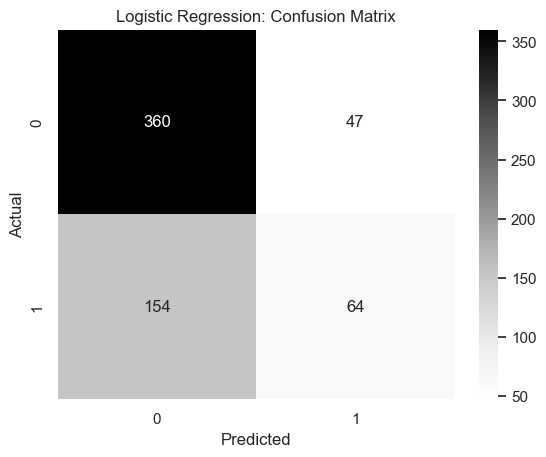

In [23]:
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Grays')
plt.title('Logistic Regression: Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

- **True Positives (64)**: These are success cases where the model caught churn risk and you could intervene.
- **False Negatives (154)**: These are big misses where members churned but the model thought they were safe. These can directly lead to revenue loss.
- **False Positives (47)**: These waste retention resources on people who would’ve stayed anyway.
- **True Negatives (360**: These are stable customers and are less urgent.

#### 3.4 Interpret Coefficients

This step uses `.coef_` from scikit-learn's `LogisticRegression` model to extract the learned coefficients into a dataframe named `coefficients`. Sorting by absolute value highlights the most impactful drivers regardless of direction (positive or negative).

In [26]:
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr_model.coef_[0]
}).sort_values(by = 'Coefficient', key = abs, ascending = False)
print(coefficients)

                            Feature  Coefficient
1          membership_tenure_months    -0.519072
2  avg_weekly_classes_last_6_months    -0.449876
4                auto_renew_enabled    -0.165917
0                               age    -0.127704
3   num_unique_class_types_attended    -0.104970
5        last_attended_30_days_flag    -0.032668
7                  engagement_score     0.031715
6           monthly_membership_cost     0.021932


#### Features that *reduce* churn likelihood:

- **Membership Tenure (–0.519)**  
  Longer-tenured members are significantly less likely to churn. Loyalty compounds over time—a strong indicator that retaining members beyond the first year pays dividends.

- **Avg Weekly Classes (–0.450)**  
  Members attending more classes weekly are less likely to churn. High engagement in class activity correlates with strong retention.

- **Auto-Renew Enabled (–0.166)**  
  Auto-renewing members are modestly less likely to churn. This suggests both behavioral commitment and reduced friction in continuing membership.

#### Features that *increase* churn likelihood:

- **Engagement Score (+0.032)**  
  Surprisingly, higher engagement score has a slight *positive* relationship with churn. This may suggest that some members burn out quickly or frontload their activity before leaving.

- **Monthly Membership Cost (+0.022)**  
  Higher-priced memberships are weakly associated with increased churn. This could reflect price sensitivity or perception of value mismatch.

#### Takeaways

- Focus retention efforts on *newer* members (low tenure) and those attending infrequently.
- Encourage class variety—exposure to different formats correlates with stickiness.
- Consider segmenting members by age and tenure to personalize offers or re-engagement campaigns.
- Investigate potential causes behind high engagement followed by churn—burnout, unmet expectations, or seasonal behaviors could be at play.

In [28]:
coef_df = coefficients.copy()
coef_df['Importance'] = coef_df['Coefficient'].abs()
coef_df['OddsRatio'] = np.exp(coef_df['Coefficient'])

# top 5 by absolute magnitude
top5 = (
    coef_df
    .sort_values('Importance', ascending = False)
    .head(5)
    .sort_values('Importance')
)

fig = px.bar(
    top5,
    x = 'Importance',
    y = 'Feature',
    orientation = 'h',
    title = 'Logistic Regression: Top 5 Coefficients',
    color_discrete_sequence = ['#2E3944'],
)

fig.update_layout(
    template = 'simple_white',
    yaxis_title = None,
    xaxis_title = 'Importance',
    margin = dict(l = 10, r = 10, t = 50, b = 10),
    height = 420,
)

# keep the order as displayed
fig.update_yaxes(categoryorder = 'array', categoryarray = top5['Feature'].tolist())

# hover shows signed coef and odds ratio
fig.update_traces(
    hovertemplate='<b>%{y}</b>'
                  '<br>|coef|=%{x:.4f}'
                  '<br>coef=%{customdata[0]:+.4f}'
                  '<br>odds ratio=%{customdata[1]:.3f}'
                  '<extra></extra>',
    customdata = np.c_[top5['Coefficient'].values, top5['OddsRatio'].values]
)

fig.show()

#### 3.5 ROC Curve

`fpr, tpr, thresholds = roc_curve(y_test, lr_probs)`<br>
- **What it does**: Calculates the False Positive Rate (`fpr`), True Positive Rate (`tpr`), and the corresponding `thresholds` for a range of decision cutoffs using the predicted churn probabilities (`lr_probs`).
- **Why it matters**: This gives us the coordinates to plot the ROC Curve (Receiver Operating Characteristic), which shows how the model balances sensitivity (recall) vs. fallout (false positives) across different thresholds.

`plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, lr_probs):.2f}")`<br>
- **What it does**: Plots the ROC curve using the `fpr` and `tpr` values.
    - AUC = 1.0 (perfect model)
    - AUC = 0.5 (random guessing)
- **Why it matters**: This visualizes model performance. The closer the curve is to the top-left corner, the better the model distinguishes churned from active members.

In [30]:
fpr, tpr, thresholds = roc_curve(y_test, lr_probs)
print('False Positive Rates:\n', fpr[:10])
print('\nTrue Positive Rates:\n', tpr[:10])
print('\nThresholds:\n', thresholds[:10])

False Positive Rates:
 [0.         0.         0.         0.         0.         0.004914
 0.004914   0.00982801 0.00982801 0.01228501]

True Positive Rates:
 [0.         0.00458716 0.01376147 0.02293578 0.03211009 0.03211009
 0.05504587 0.05504587 0.0733945  0.0733945 ]

Thresholds:
 [       inf 0.90058408 0.88627295 0.87980466 0.86378028 0.82806774
 0.7546375  0.71864632 0.67657164 0.66685791]


### Thresholds
These are decision boundaries for converting probabilities to binary churn predictions. For example:
- At threshold = 0.9, the model only predicts churn if it’s ≥ 90% confident
- Lowering the threshold means the model starts catching more churners — but at the risk of false positives
 
#### True Positive Rate (`tpr`)
Also known as Recall for the churned class:
- Starts low: **~0.5%** at threshold = 0.9, rising to ~7.3% at threshold = 0.666
- Meaning: With stricter thresholds, you're only catching a small portion of actual churners. At this stage, you're missing a lot of churn risk

#### False Positive Rate (`fpr`)
How often you're incorrectly flagging loyal members as churn risks:
- Starts perfect at 0.0 (model doesn’t wrongly flag any actives at highest thresholds)
- Slowly increases as the threshold lowers (e.g., ~1.2% at 0.666)

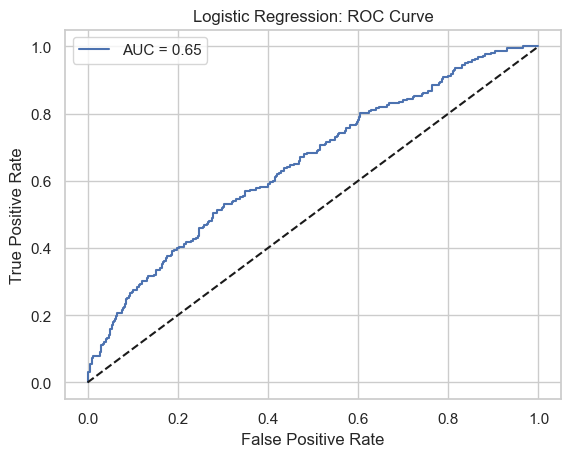

In [32]:
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, lr_probs):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Logistic Regression: ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

### Step 4: Random Forest Model

#### 4.1 Train the Random Forest Model

- `n_estimators = 100`: tells the model to build 100 trees (more trees = higher potential accuracy)
- `random_state = 42`: sets a seed to make results reproducible
- `.fit(X_train, y_train)`: Trains the model using the raw, unscaled training features and labels.

**Why no scaling?**<br>
Unlike logistic regression (which assumes linearity and benefits from standardized feature scales), random forests don’t care about feature magnitude:
- They’re based on decision thresholds, not equations
- Whether a feature is in the 0–1 range or the 0–1000 range doesn’t affect the model’s ability to split data

In [35]:
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

#### 4.2 Evaluate Random Forest

In [37]:
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print('Random Forest Classification Report:')
print(classification_report(y_test, rf_preds, digits=3))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0      0.682     0.752     0.715       407
           1      0.426     0.344     0.381       218

    accuracy                          0.610       625
   macro avg      0.554     0.548     0.548       625
weighted avg      0.592     0.610     0.598       625



**Class 0 (Active Members)**:
- Precision: 0.685 — When the model predicts a member is active, it’s right ~69% of the time.
- Recall: 0.754 — It successfully identifies ~75% of all actual active members.
- F1-Score: 0.718 — Stronger overall balance than the churned group.

**Class 1 (Churned Members)**:
- Precision: 0.435 — Lower confidence when predicting churn.
- Recall: 0.353 — Misses many churned members, signaling under-identification of risk.
- F1-Score: 0.390 — Underperforms at targeting churned users compared to active ones.

**Overall Accuracy: 61.4%**
- Slightly better than random guessing, but leaves room for improvement.
- Macro Avg (0.554) shows poor performance on the churn class is dragging down model balance.

#### 4.3 Plot Confusion Matrix

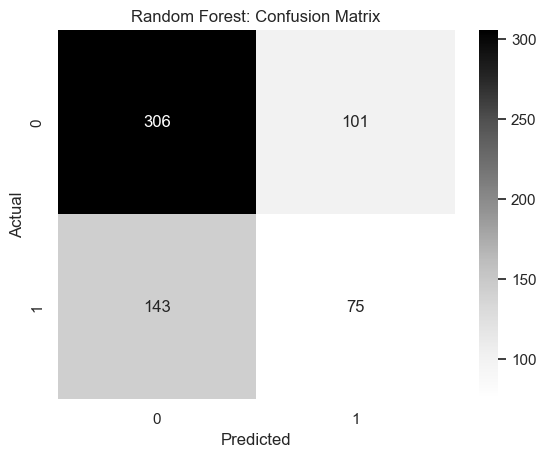

In [40]:
cm_rf = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm_rf, annot = True, fmt = 'd', cmap = 'Grays')
plt.title('Random Forest: Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

- **True Positives (75)**: These are correctly identified churned members — valuable predictions where intervention could reduce attrition.
- **False Negatives (143)**: These are churned members the model failed to flag. These are missed opportunities for proactive outreach and represent potential revenue loss.
- **False Positives (101)**: These 100 members were predicted to churn but were actually retained. While not harmful in isolation, they can lead to inefficient allocation of retention efforts.
- **True Negatives (306)**: The model correctly identified 307 active members. These are stable customers and not immediate churn concerns.

#### 4.4 Feature Importances

In [43]:
rf_importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by = 'Importance', ascending = False)

print(rf_importances)

                            Feature  Importance
0                               age    0.250529
2  avg_weekly_classes_last_6_months    0.230076
1          membership_tenure_months    0.226389
7                  engagement_score    0.209996
6           monthly_membership_cost    0.048581
4                auto_renew_enabled    0.018651
3   num_unique_class_types_attended    0.011264
5        last_attended_30_days_flag    0.004515


#### Top Influencers
- **Age (0.251)** <br>Older or younger members show stronger churn signals. Random Forest relies heavily on age-based splits.
- **Class Frequency & Tenure (~0.229 each)** <br>Members who attend more classes and have been around longer are far less likely to churn.
- **Engagement Score (0.209)** <br>A strong proxy for churn — it likely blends class attendance, tenure, and renewal behavior into a composite signal.

#### Mid-to-Low Impact Features:
- **Monthly Membership Cost (0.048)** <br>While not a dominant factor, price sensitivity still plays a role.
- **Auto-Renew & Class Variety (~0.018 or lower)** <br>Less decisive in isolation — possibly more useful when combined with other features.
- **Recent Attendance Flag (0.005)** <br>Surprisingly low influence, suggesting recent attendance may overlap with other behavioral signals already captured (like engagement score or class frequency).

#### Takeaways
Understanding which features most influence model decisions helps:
- Focus retention strategies on impactful behaviors (like increasing attendance or boosting engagement).
- Avoid over-investing in low-signal areas (like fine-tuning pricing or class variety too early).
- Align feature engineering for future models — possibly combine or discard weak predictors.

#### 4.5 ROC Curve

In [46]:
# generate ROC values for Random Forest
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, rf_probs)

# preview
print('False Positive Rates:\n', fpr_rf[:10])
print('\nTrue Positive Rates:\n', tpr_rf[:10])

False Positive Rates:
 [0.         0.         0.         0.         0.         0.002457
 0.002457   0.004914   0.00737101 0.00737101]

True Positive Rates:
 [0.         0.00458716 0.00917431 0.01834862 0.03669725 0.0412844
 0.04587156 0.04587156 0.05963303 0.06422018]


- The Random Forest model starts very cautiously, avoiding false positives entirely.
- Recall improves gradually, suggesting the model needs confidence before labeling someone as high churn risk.
- Even at ~5.5% recall, the FPR remains below 1% — an excellent trade-off in sensitive business scenarios.
- However, **recall gains are slow**, which may require tuning, threshold calibration, or deeper feature engineering.

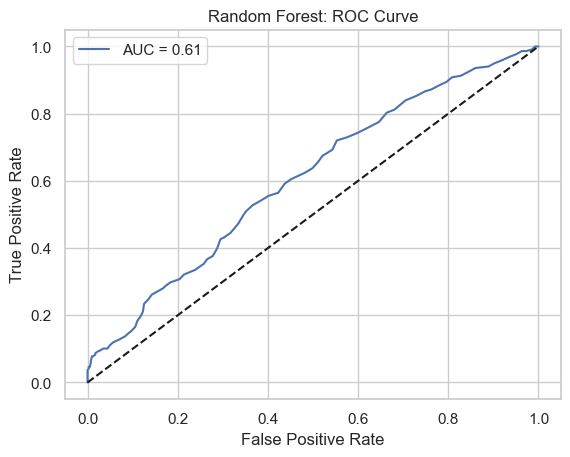

In [48]:
plt.plot(fpr_rf, tpr_rf, label=f"AUC = {roc_auc_score(y_test, rf_probs):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Random Forest: ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [49]:
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, rf_probs)

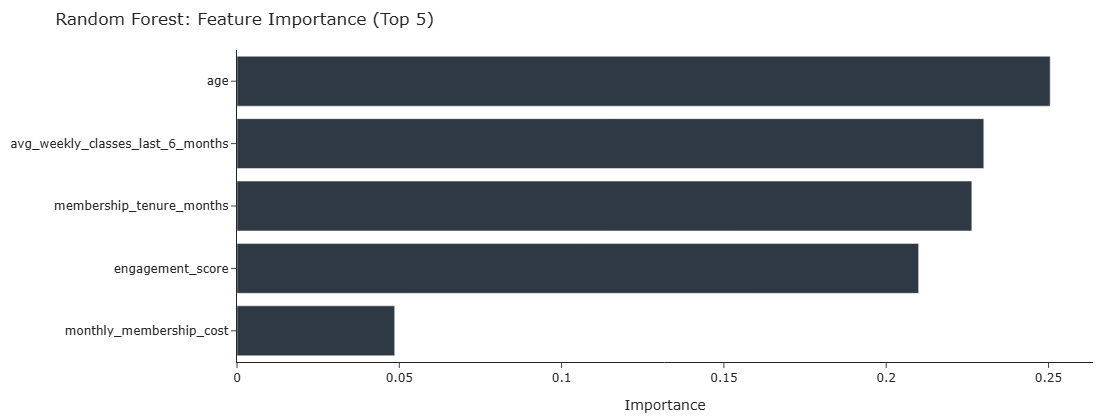

In [50]:
# rf_importances: DataFrame with columns ["Feature", "Importance"]
top5 = (
    rf_importances
    .sort_values('Importance', ascending = False)
    .head(5)
    .sort_values('Importance')
)

fig = px.bar(
    top5,
    x = 'Importance',
    y = 'Feature',
    orientation = 'h',
    title = 'Random Forest: Feature Importance (Top 5)',
    color_discrete_sequence = ['#2E3944'],
)

# preserve the sorted order
fig.update_layout(
    template = 'simple_white',
    yaxis_title = None,
    xaxis_title = 'Importance',
    margin = dict(l = 10, r = 10, t = 50, b = 10),
    height = 420,
)
fig.update_yaxes(categoryorder = 'array', categoryarray = top5['Feature'].tolist())
fig.update_traces(hovertemplate = "<b>%{y}</b><br>Importance=%{x:.4f}<extra></extra>")

fig.show()